# 岁月织机 — 训练 Notebook

**中国民乐五声部音源分离模型训练**

架构：BS-RoFormer（Band-Split Rotary Transformer）  
声部：`erhu` / `wind` / `plucked` / `perc` / `vocal`  
损失：多分辨率 STFT Loss（n_fft = 512 / 2048 / 8192）

---

## Cell 0 · 配置（上 HPC 只改这里）

In [ ]:
import pathlib
import os
import torch

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ── 路径 ──────────────────────────────────────────────────────────────────────
DATASET_ROOT = pathlib.Path("../music/dataset")              # 本地
# DATASET_ROOT = pathlib.Path("/root/autodl-tmp/dataset_balanced")  # HPC
CKPT_DIR     = pathlib.Path("checkpoints")
LOG_DIR      = pathlib.Path("runs")

# ── 运行模式 ──────────────────────────────────────────────────────────────────
LOCAL = True   # 本地调试=True，HPC训练=False

if LOCAL:
    EPOCHS       = 5
    BATCH_SIZE   = 1
    ACCUM_STEPS  = 4          # effective batch = 4
    LR           = 3e-4
    WEIGHT_DECAY = 1e-2
    GRAD_CLIP    = 5.0
    VAL_RATIO    = 0.05
    NUM_WORKERS  = 0
    SAVE_EVERY   = 2
    SR           = 22050
    MODEL_DIM    = 64
    MODEL_DEPTH  = 2
else:
    # 3卡5090 96GB — 每卡 batch=4，effective = 12
    EPOCHS       = 100
    BATCH_SIZE   = 4
    ACCUM_STEPS  = 1
    LR           = 3e-4
    WEIGHT_DECAY = 1e-2
    GRAD_CLIP    = 5.0
    VAL_RATIO    = 0.05
    NUM_WORKERS  = 4
    SAVE_EVERY   = 5
    SR           = 22050
    MODEL_DIM    = 256
    MODEL_DEPTH  = 6

# ── 设备 & DDP 检测 ───────────────────────────────────────────────────────────
USE_DDP = not LOCAL and torch.cuda.device_count() > 1

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
print(f"模式         : {'本地 MPS' if LOCAL else 'HPC CUDA'}")
print(f"设备         : {device}  (GPU数={torch.cuda.device_count() if torch.cuda.is_available() else 0})")
print(f"DDP          : {'开启' if USE_DDP else '关闭'}")
print(f"DATASET_ROOT : {DATASET_ROOT.resolve()}")
print(f"BATCH_SIZE   : {BATCH_SIZE}  accum={ACCUM_STEPS}  effective={BATCH_SIZE*ACCUM_STEPS*(torch.cuda.device_count() if USE_DDP else 1)}")
print(f"MODEL        : dim={MODEL_DIM}  depth={MODEL_DEPTH}")

## Cell 1 · 环境检查

In [8]:
import torch
import sys

print(f"Python      : {sys.version.split()[0]}")
print(f"PyTorch     : {torch.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    n_gpu  = torch.cuda.device_count()
    for i in range(n_gpu):
        prop = torch.cuda.get_device_properties(i)
        vram = prop.total_memory / 1024**3
        print(f"GPU {i}       : {prop.name}  VRAM={vram:.1f} GB")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("GPU         : Apple MPS")
else:
    device = torch.device("cpu")
    print("GPU         : 无，使用 CPU（速度较慢）")

print(f"\n训练设备    : {device}")

Python      : 3.12.4
PyTorch     : 2.11.0
GPU         : Apple MPS

训练设备    : mps


## Cell 2 · 数据集探索

数据集总长度 : 4,500 样本

各轨道片段数（6s / 3s overlap）：
  erhu      :  4,500 片段  7.5h
  wind      :  4,500 片段  7.5h
  plucked   :  4,500 片段  7.5h
  perc      :  3,914 片段  6.5h
  vocal     :  4,500 片段  7.5h


/var/folders/7d/m63m8l9x7lv56tttllnct7_80000gn/T/ipykernel_3649/3654448110.py:39: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7d/m63m8l9x7lv56tttllnct7_80000gn/T/ipykernel_3649/3654448110.py:39: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7d/m63m8l9x7lv56tttllnct7_80000gn/T/ipykernel_3649/3654448110.py:39: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7d/m63m8l9x7lv56tttllnct7_80000gn/T/ipykernel_3649/3654448110.py:39: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7d/m63m8l9x7lv56tttllnct7_80000gn/T/ipykernel_3649/3654448110.py:39: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7d/m63m8l9x7

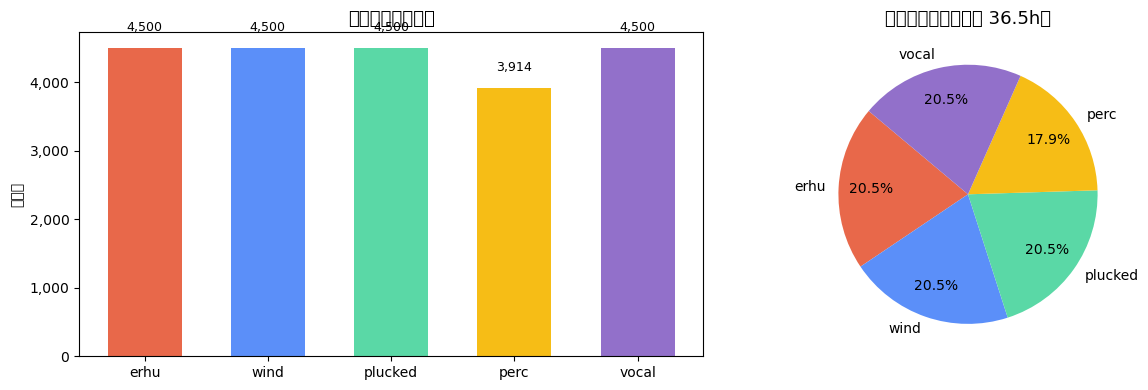

图表已保存至 runs/dataset_overview.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from dataset import DynamicMixDataset, STEMS, make_loaders

# 加载数据集
full_ds = DynamicMixDataset(DATASET_ROOT)
pool_sizes = {s: len(full_ds.pools[s]) for s in STEMS}
total_clips = sum(pool_sizes.values())

print(f"数据集总长度 : {len(full_ds):,} 样本")
print(f"\n各轨道片段数（6s / 3s overlap）：")
for s, n in pool_sizes.items():
    hours = n * 6 / 3600
    print(f"  {s:10s}: {n:6,} 片段  {hours:.1f}h")

# ── 柱状图 ────────────────────────────────────────────────────────────────────
colors = ['#E8684A', '#5B8FF9', '#5AD8A6', '#F6BD16', '#9270CA']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 左：片段数
bars = axes[0].bar(STEMS, [pool_sizes[s] for s in STEMS], color=colors, width=0.6)
axes[0].set_title("各轨道训练片段数", fontsize=13)
axes[0].set_ylabel("片段数")
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, stem in zip(bars, STEMS):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{pool_sizes[stem]:,}", ha='center', va='bottom', fontsize=9)

# 右：时长饼图
hours = [pool_sizes[s] * 6 / 3600 for s in STEMS]
wedges, texts, autotexts = axes[1].pie(
    hours, labels=STEMS, colors=colors,
    autopct='%1.1f%%', startangle=140,
    pctdistance=0.75, labeldistance=1.1
)
axes[1].set_title(f"训练时长分布（总计 {sum(hours):.1f}h）", fontsize=13)

plt.tight_layout()
plt.savefig(LOG_DIR / "dataset_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"图表已保存至 {LOG_DIR / 'dataset_overview.png'}")

## Cell 3 · 动态混音样本可视化

/var/folders/7d/m63m8l9x7lv56tttllnct7_80000gn/T/ipykernel_3649/1771715724.py:31: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7d/m63m8l9x7lv56tttllnct7_80000gn/T/ipykernel_3649/1771715724.py:31: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7d/m63m8l9x7lv56tttllnct7_80000gn/T/ipykernel_3649/1771715724.py:31: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7d/m63m8l9x7lv56tttllnct7_80000gn/T/ipykernel_3649/1771715724.py:31: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7d/m63m8l9x7lv56tttllnct7_80000gn/T/ipykernel_3649/1771715724.py:31: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7d/m63m8l9x7

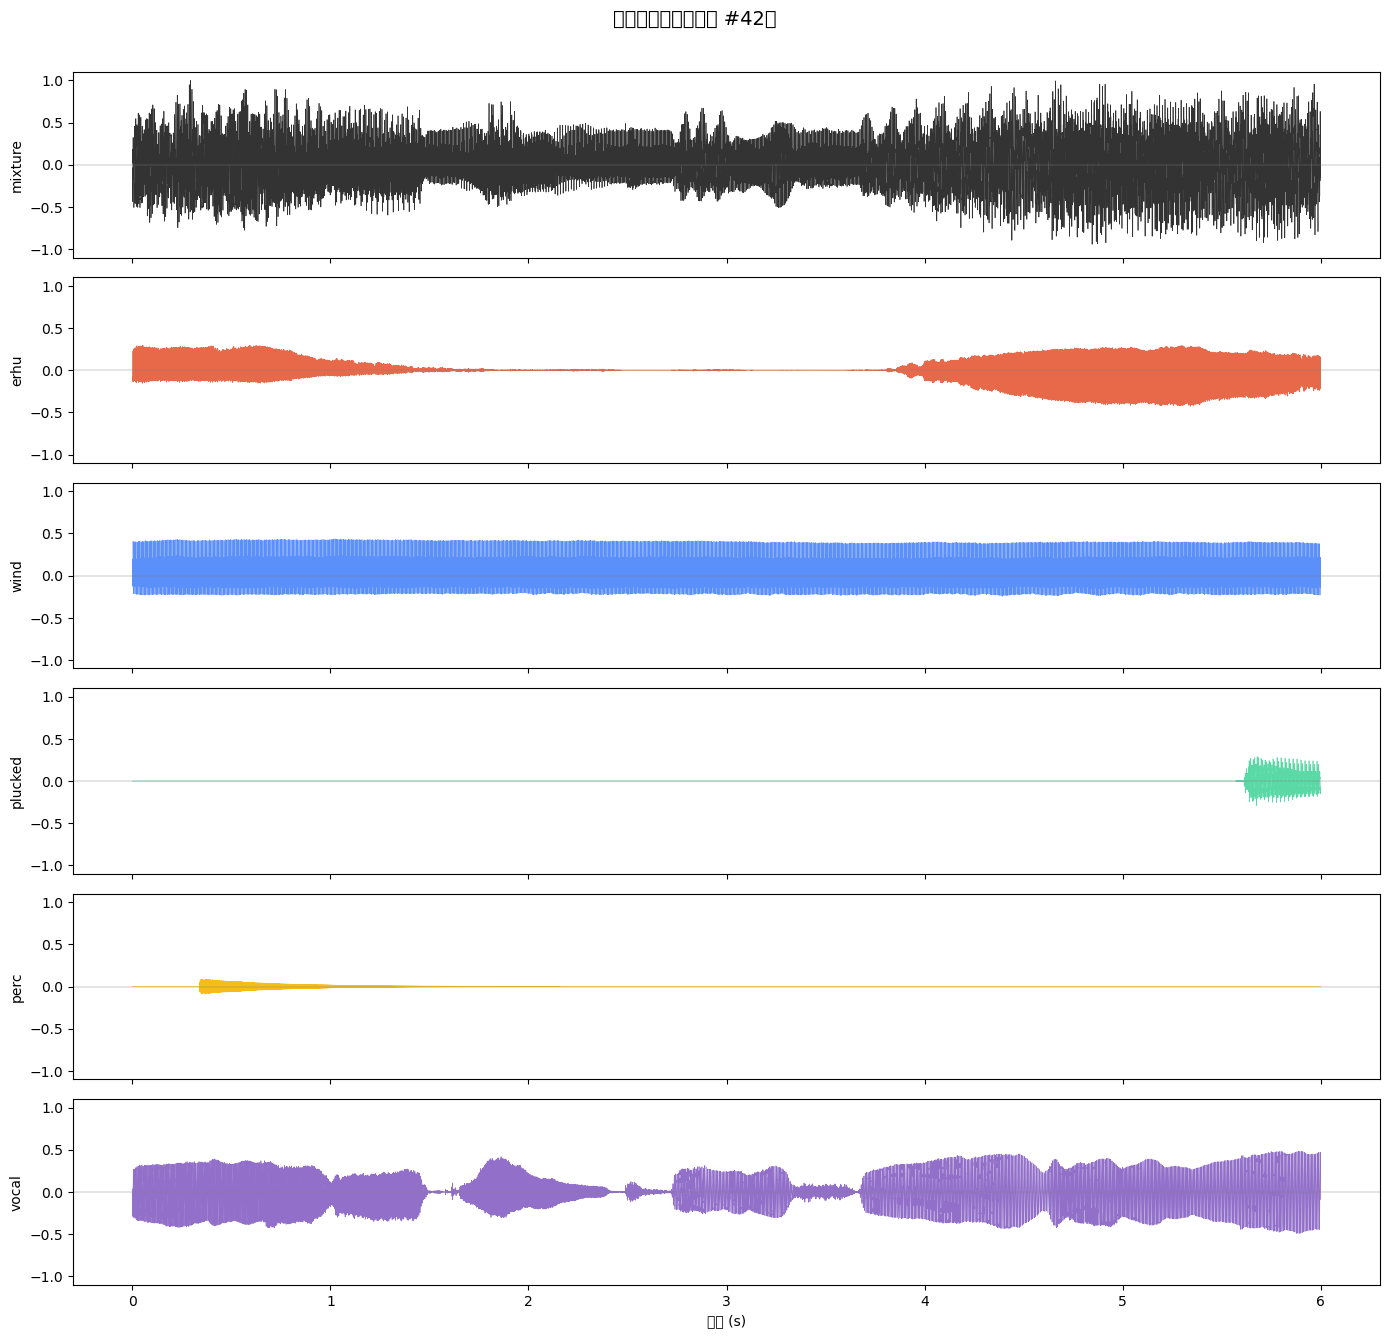

活跃声部: ['erhu', 'wind', 'plucked', 'perc', 'vocal']


In [10]:
import soundfile as sf

# 取一个样本
mixture, stems_audio, active = full_ds[42]

t = np.linspace(0, 6, mixture.shape[-1])
n_stems = len(STEMS)

fig, axes = plt.subplots(n_stems + 1, 1, figsize=(14, 2.2 * (n_stems + 1)),
                         sharex=True)
fig.suptitle("动态混音样本（样本 #42）", fontsize=14, y=1.01)

# 混合波形
axes[0].plot(t, mixture[0].numpy(), color='#333333', linewidth=0.5)
axes[0].set_ylabel("mixture", fontsize=10)
axes[0].set_ylim(-1.1, 1.1)
axes[0].axhline(0, color='gray', linewidth=0.3)

# 各 stem
for ax, stem, color in zip(axes[1:], STEMS, colors):
    audio = stems_audio[stem][0].numpy()
    ax.plot(t, audio, color=color, linewidth=0.5)
    label = stem if active[stem] else f"{stem}  [静音]"
    ax.set_ylabel(label, fontsize=10)
    ax.set_ylim(-1.1, 1.1)
    ax.axhline(0, color='gray', linewidth=0.3)
    if not active[stem]:
        ax.set_facecolor('#fff5f5')

axes[-1].set_xlabel("时间 (s)", fontsize=10)
plt.tight_layout()
plt.savefig(LOG_DIR / "sample_waveforms.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"活跃声部: {[s for s in STEMS if active[s]]}")

## Cell 4 · 模型构建

In [ ]:
import torch.nn as nn
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from bs_roformer import BSRoformer
from auraloss.freq import MultiResolutionSTFTLoss

# ── DDP 初始化 ────────────────────────────────────────────────────────────────
if USE_DDP:
    dist.init_process_group("nccl")
    local_rank = int(os.environ["LOCAL_RANK"])
    torch.cuda.set_device(local_rank)
    device = torch.device(f"cuda:{local_rank}")
    print(f"DDP rank={dist.get_rank()}  local_rank={local_rank}  world={dist.get_world_size()}")

# ── 模型 ──────────────────────────────────────────────────────────────────────
_model = BSRoformer(
    dim                    = MODEL_DIM,
    depth                  = MODEL_DEPTH,
    heads                  = 8,
    dim_head               = 32,
    num_stems              = len(STEMS),
    time_transformer_depth = 2,
    freq_transformer_depth = 1,
).to(device)

if USE_DDP:
    model = DDP(_model, device_ids=[local_rank])
else:
    model = _model

# ── 损失函数 ──────────────────────────────────────────────────────────────────
loss_fn = MultiResolutionSTFTLoss(
    fft_sizes   = [512, 2048, 8192],
    hop_sizes   = [128,  512, 2048],
    win_lengths = [512, 2048, 8192],
).to(device)

# ── 优化器 ────────────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    _model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=LR * 1e-2
)

total_params = sum(p.numel() for p in _model.parameters())
print(f"模型     : BSRoformer  dim={MODEL_DIM}  depth={MODEL_DEPTH}")
print(f"参数量   : {total_params/1e6:.1f}M")
print(f"并行模式 : {'DDP' if USE_DDP else '单卡/MPS'}")

## Cell 5 · 训练循环（含实时 Loss 曲线）

In [ ]:
import time
import json
from IPython.display import clear_output
from tqdm.notebook import tqdm
from torch.utils.data import DistributedSampler

# ── DataLoader（DDP 用 DistributedSampler）────────────────────────────────────
if USE_DDP:
    full_ds  = DynamicMixDataset(DATASET_ROOT, augment=True)
    total    = len(full_ds)
    n_val    = max(1, int(total * VAL_RATIO))
    n_train  = total - n_val
    rng      = torch.Generator().manual_seed(42)
    train_ds, val_ds = torch.utils.data.random_split(full_ds, [n_train, n_val], generator=rng)
    val_ds_clean     = DynamicMixDataset(DATASET_ROOT, augment=False)
    val_ds           = torch.utils.data.Subset(val_ds_clean, val_ds.indices)

    world_size = dist.get_world_size()
    rank       = dist.get_rank()
    train_sampler = DistributedSampler(train_ds, num_replicas=world_size, rank=rank, shuffle=True, drop_last=True)
    val_sampler   = DistributedSampler(val_ds,   num_replicas=world_size, rank=rank, shuffle=False)

    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler,
                                               num_workers=NUM_WORKERS, pin_memory=True,
                                               persistent_workers=NUM_WORKERS>0)
    val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=BATCH_SIZE, sampler=val_sampler,
                                               num_workers=NUM_WORKERS, pin_memory=True,
                                               persistent_workers=NUM_WORKERS>0)
    is_main = rank == 0
else:
    train_loader, val_loader = make_loaders(
        dataset_root=DATASET_ROOT, batch_size=BATCH_SIZE,
        val_ratio=VAL_RATIO, num_workers=NUM_WORKERS,
    )
    train_sampler = None
    is_main = True

print(f"训练集: {len(train_loader.dataset):,} 样本  ({len(train_loader)} batches)")
print(f"验证集: {len(val_loader.dataset):,} 样本  ({len(val_loader)} batches)")

# ── 损失计算 ──────────────────────────────────────────────────────────────────
def compute_loss(pred_stems, true_stems, active):
    total, count = torch.tensor(0.0, device=device), 0
    for i, stem in enumerate(STEMS):
        mask = torch.tensor(active[stem], dtype=torch.bool, device=device)
        if not mask.any():
            continue
        pred = pred_stems[:, i].squeeze(1)[mask].unsqueeze(1)
        true = true_stems[stem][mask]
        t    = min(pred.shape[-1], true.shape[-1])
        total = total + loss_fn(pred[..., :t], true[..., :t])
        count += 1
    return total / max(count, 1)

# ── 实时图表（仅主进程）──────────────────────────────────────────────────────
def plot_live(train_losses, val_losses, epoch, elapsed_min):
    clear_output(wait=True)
    epochs_x = list(range(1, len(train_losses) + 1))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"岁月织机  |  Epoch {epoch}/{EPOCHS}  |  已用 {elapsed_min:.1f} min", fontsize=13)
    for ax, recent in zip(axes, [False, True]):
        n = min(10, len(train_losses)) if recent else len(train_losses)
        ax.plot(epochs_x[-n:], train_losses[-n:], 'o-', color='#5B8FF9', linewidth=1.5, markersize=3, label='Train')
        ax.plot(epochs_x[-n:], val_losses[-n:],   's-', color='#E8684A', linewidth=1.5, markersize=3, label='Val')
        ax.set_xlabel("Epoch"); ax.set_ylabel("STFT Loss")
        ax.set_title("完整曲线" if not recent else f"最近 {n} Epoch")
        ax.legend(); ax.grid(alpha=0.3)
        if train_losses: ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.savefig(LOG_DIR / "loss_curve.png", dpi=120, bbox_inches='tight')
    plt.show()
    if train_losses:
        best_ep = val_losses.index(min(val_losses)) + 1
        print(f"  train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}  best={min(val_losses):.4f} @ep{best_ep}")

# ── checkpoint 保存 ───────────────────────────────────────────────────────────
def save_ckpt(path, avg_val):
    torch.save({
        'epoch':     epoch,
        'model':     _model.state_dict(),
        'model_cfg': {'dim': MODEL_DIM, 'depth': MODEL_DEPTH,
                      'heads': 8, 'dim_head': 32,
                      'time_transformer_depth': 2, 'freq_transformer_depth': 1},
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'val_loss':  avg_val,
        'stems':     STEMS,
    }, path)

# ── 断点续训 ──────────────────────────────────────────────────────────────────
history_path = LOG_DIR / "history.json"
train_losses, val_losses = [], []
start_epoch  = 0
best_val     = float('inf')

last_ckpt = CKPT_DIR / "last.pt"
if last_ckpt.exists():
    print(f"发现 checkpoint：{last_ckpt}，继续训练？")
    ans = input("y 继续，其他重新开始：").strip().lower()
    if ans == 'y':
        ckpt = torch.load(last_ckpt, map_location=device, weights_only=False)
        _model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        start_epoch = ckpt['epoch'] + 1
        if history_path.exists():
            h = json.loads(history_path.read_text())
            train_losses, val_losses = h['train'], h['val']
            best_val = min(val_losses) if val_losses else float('inf')
        print(f"从 epoch {start_epoch} 继续，best_val={best_val:.4f}")

# ── 主训练循环 ────────────────────────────────────────────────────────────────
t_start = time.time()

for epoch in range(start_epoch, EPOCHS):
    t_epoch = time.time()

    if train_sampler is not None:
        train_sampler.set_epoch(epoch)

    # Train
    model.train()
    epoch_train_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:03d} [train]", leave=False, ncols=90) if is_main else train_loader
    for step, (mixture, stems_true, active) in enumerate(pbar):
        mixture    = mixture.to(device)
        stems_true = {s: v.to(device) for s, v in stems_true.items()}

        pred = model(mixture.squeeze(1))
        loss = compute_loss(pred, stems_true, active) / ACCUM_STEPS
        loss.backward()
        epoch_train_loss += loss.item() * ACCUM_STEPS

        if (step + 1) % ACCUM_STEPS == 0:
            nn.utils.clip_grad_norm_(_model.parameters(), GRAD_CLIP)
            optimizer.step()
            optimizer.zero_grad()

        if is_main and hasattr(pbar, 'set_postfix'):
            pbar.set_postfix(loss=f"{loss.item()*ACCUM_STEPS:.4f}")

    if (step + 1) % ACCUM_STEPS != 0:
        nn.utils.clip_grad_norm_(_model.parameters(), GRAD_CLIP)
        optimizer.step()
        optimizer.zero_grad()

    scheduler.step()
    avg_train = epoch_train_loss / len(train_loader)

    # 跨卡汇总 loss
    if USE_DDP:
        t = torch.tensor(avg_train, device=device)
        dist.all_reduce(t, op=dist.ReduceOp.AVG)
        avg_train = t.item()

    # Validation
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for mixture, stems_true, active in val_loader:
            mixture    = mixture.to(device)
            stems_true = {s: v.to(device) for s, v in stems_true.items()}
            pred       = model(mixture.squeeze(1))
            loss       = compute_loss(pred, stems_true, active)
            epoch_val_loss += loss.item()

    avg_val = epoch_val_loss / len(val_loader)
    if USE_DDP:
        t = torch.tensor(avg_val, device=device)
        dist.all_reduce(t, op=dist.ReduceOp.AVG)
        avg_val = t.item()

    elapsed = (time.time() - t_start) / 60

    # 主进程负责记录和保存
    if is_main:
        train_losses.append(avg_train)
        val_losses.append(avg_val)
        history_path.write_text(json.dumps({'train': train_losses, 'val': val_losses}))
        plot_live(train_losses, val_losses, epoch + 1, elapsed)
        lr_now = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch+1:03d}/{EPOCHS}  train={avg_train:.4f}  val={avg_val:.4f}  "
              f"lr={lr_now:.2e}  time={time.time()-t_epoch:.0f}s")

        save_ckpt(CKPT_DIR / 'last.pt', avg_val)
        if (epoch + 1) % SAVE_EVERY == 0:
            save_ckpt(CKPT_DIR / f'epoch_{epoch+1:03d}.pt', avg_val)
        if avg_val <= best_val:
            best_val = avg_val
            save_ckpt(CKPT_DIR / 'best.pt', avg_val)
            print(f"  ★ 新最佳 val={best_val:.4f}")

    if USE_DDP:
        dist.barrier()

if USE_DDP:
    dist.destroy_process_group()

print("\n训练完成！")
if is_main:
    print(f"最佳 val loss: {best_val:.4f}")
    print(f"Best checkpoint: {(CKPT_DIR / 'best.pt').resolve()}")

## Cell 6 · 训练结束后 Loss 详细分析

In [ ]:
import json

# 读取历史（支持在训练结束后单独运行这格）
if not train_losses:
    history = json.loads((LOG_DIR / 'history.json').read_text())
    train_losses = history['train']
    val_losses   = history['val']

epochs_x  = list(range(1, len(train_losses) + 1))
best_ep   = val_losses.index(min(val_losses)) + 1
best_val  = min(val_losses)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("训练结果分析", fontsize=14)

# ① 完整 Loss 曲线
axes[0].plot(epochs_x, train_losses, color='#5B8FF9', linewidth=1.5, label='Train')
axes[0].plot(epochs_x, val_losses,   color='#E8684A', linewidth=1.5, label='Val')
axes[0].axvline(best_ep, color='green', linestyle='--', alpha=0.7,
                label=f'Best val (ep {best_ep})')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("STFT Loss")
axes[0].set_title("完整 Loss 曲线"); axes[0].legend(); axes[0].grid(alpha=0.3)

# ② Train - Val Gap（过拟合监测）
gap = [v - t for t, v in zip(train_losses, val_losses)]
axes[1].fill_between(epochs_x, 0, gap, alpha=0.3,
                      color='#F6BD16' if max(gap) < 0.5 else '#E8684A')
axes[1].plot(epochs_x, gap, color='#F6BD16', linewidth=1.5)
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val - Train")
axes[1].set_title("过拟合监测（Val - Train Gap）"); axes[1].grid(alpha=0.3)

# ③ Loss 下降速率
delta = [0] + [train_losses[i-1] - train_losses[i] for i in range(1, len(train_losses))]
axes[2].bar(epochs_x, delta, color=['#5AD8A6' if d > 0 else '#E8684A' for d in delta],
            width=0.8)
axes[2].axhline(0, color='gray', linewidth=0.5)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Loss 下降量")
axes[2].set_title("每 Epoch 训练 Loss 下降速率"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(LOG_DIR / 'training_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"最终 train loss : {train_losses[-1]:.4f}")
print(f"最终 val loss   : {val_losses[-1]:.4f}")
print(f"最佳 val loss   : {best_val:.4f}  @ epoch {best_ep}")

## Cell 7 · 分离效果预览（Mel 频谱图）

In [ ]:
import torchaudio
import torchaudio.transforms as T

# 加载 best checkpoint
ckpt = torch.load(CKPT_DIR / 'best.pt', map_location=device)
model.load_state_dict(ckpt['model'])
model.eval()
print(f"加载 best checkpoint (epoch {ckpt['epoch']+1}, val_loss={ckpt['val_loss']:.4f})")

# 取一个测试样本
test_idx = 100
mixture, stems_true, active = full_ds[test_idx]
mix_in = mixture.unsqueeze(0).to(device)   # [1, 1, T]

with torch.no_grad():
    pred = model(mix_in.squeeze(1))        # [1, 5, 1, T_pred]

# Mel 频谱变换
mel_transform = T.MelSpectrogram(
    sample_rate=SR, n_fft=2048, hop_length=512,
    n_mels=80, f_min=50, f_max=10000
).to(device)

def to_mel_db(waveform):
    mel = mel_transform(waveform)          # [1, n_mels, T]
    return (mel + 1e-7).log2().squeeze().cpu().numpy()

n_plot = 1 + len(STEMS)
fig, axes = plt.subplots(n_plot, 1, figsize=(14, 2.5 * n_plot), sharex=True)
fig.suptitle(f"Mel 频谱分离结果（样本 #{test_idx}）", fontsize=13, y=1.01)

def plot_mel(ax, mel, title, color_map='magma'):
    im = ax.imshow(mel, aspect='auto', origin='lower',
                   cmap=color_map, interpolation='nearest')
    ax.set_ylabel(title, fontsize=9)
    ax.set_yticks([])
    return im

# Mixture
mix_mel = to_mel_db(mix_in.squeeze(0).cpu())
plot_mel(axes[0], mix_mel, "mixture")

# 各 stem 预测
for i, (ax, stem, color) in enumerate(zip(axes[1:], STEMS, colors)):
    stem_wav = pred[0, i].cpu()            # [1, T_pred]
    t_min    = min(stem_wav.shape[-1], mixture.shape[-1])
    stem_mel = to_mel_db(stem_wav[..., :t_min])
    plot_mel(ax, stem_mel, f"{stem} (预测)", color_map='viridis')
    if not active[stem]:
        ax.set_facecolor('#fff5f5')
        ax.set_ylabel(f"{stem} (静音)", fontsize=9)

axes[-1].set_xlabel("时间帧")
plt.tight_layout()
plt.savefig(LOG_DIR / 'separation_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"频谱图已保存至 {LOG_DIR / 'separation_preview.png'}")

## Cell 8 · 导出确认

In [ ]:
print("\n═" * 35)
print("  训练产出物")
print("═" * 35)

outputs = [
    (CKPT_DIR / 'best.pt',          '最佳模型权重'),
    (CKPT_DIR / 'last.pt',          '最后一个 epoch 权重'),
    (LOG_DIR   / 'history.json',     'Loss 历史数据'),
    (LOG_DIR   / 'loss_curve.png',   'Loss 曲线图'),
    (LOG_DIR   / 'training_analysis.png', '训练分析图'),
    (LOG_DIR   / 'dataset_overview.png',  '数据集概览图'),
    (LOG_DIR   / 'separation_preview.png','分离效果频谱图'),
]

for path, desc in outputs:
    exists = '✓' if path.exists() else '✗'
    size   = f"{path.stat().st_size/1024:.1f} KB" if path.exists() else '—'
    print(f"  {exists}  {desc:20s}  {size:10s}  {path}")

print("═" * 35)